In [128]:
import numpy as np
import tensorflow as tf
from keras.models import load_model
from keras.applications.resnet import preprocess_input
from keras.layers import Resizing, Conv2D
import os

# Cargar modelo
model = load_model('models\\Mammalia\\model_M1.h5', compile=True)  # compile=False si no necesitas recompilar

# Cargar clases
classes = np.load('models\\Mammalia\\classes.npy')
print("Clases disponibles:", classes)


Clases disponibles: ['Alouatta_seniculus' 'Bradypus_variegatus' 'Cerdocyon_thous'
 'Lontra_longicaudis' 'Panthera_onca' 'Pecari_tajacu' 'Procyon_lotor'
 'Puma_concolor' 'Sciurus_granatensis']


In [130]:
def predict_species(spec):
    """
    Realiza la predicción del nombre de la especie a partir de un espectrograma (1025, 313).
    """
    if spec.shape != (1025, 313):
        raise ValueError("El espectrograma debe tener forma (1025, 313)")

    # # Normalizar
     # Añadir canal y batch dimension
    spec = np.expand_dims(spec[..., np.newaxis], axis=0).astype('float32')  # (1, 1025, 313, 1)   
    # spec = spec
    spec /= np.max(spec)




    pred = model.predict(spec)  # type: ignore
    pred_class_idx = np.argmax(pred)
    pred_class = classes[pred_class_idx]
    prob = pred[0][pred_class_idx]

    return pred_class, prob


In [138]:
# Ruta del nuevo archivo a predecir
new_file = 'Mammalia\\NPX_1\\Puma_concolor_iNat987929_chunk1.npz'

# Cargar el espectrograma del archivo
data = np.load(new_file)
spec = data['spec']

# Hacer la predicción
predicted_species, confidence = predict_species(spec)
print(f"Especie predicha: {predicted_species} (confianza: {confidence:.2f})")


1/1 [==============================] - 0s 144ms/step
Especie predicha: Puma_concolor (confianza: 0.89)


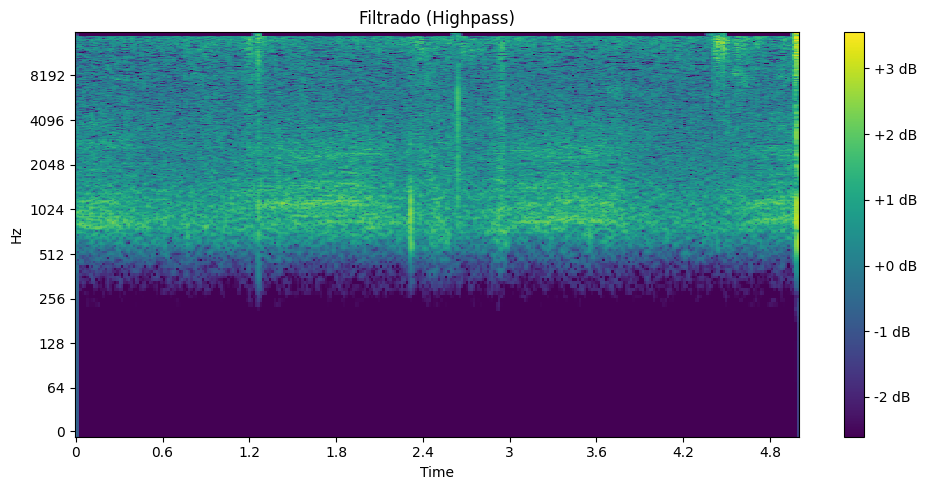

In [151]:
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio


plt.figure(figsize=(10, 5))

librosa.display.specshow(spec, sr=32000, x_axis='time', y_axis='log', cmap='viridis')
plt.title("Filtrado (Highpass)")
plt.colorbar(format='%+2.0f dB')

plt.tight_layout()
plt.show()
# S_amplitude = librosa.db_to_amplitude(spec)
# S = librosa.griffinlim(S_amplitude)

# Entonces para desnormalizar:
mean_D = np.mean(spec)
std_D = np.std(spec)
D_desnormalizado = spec * std_D + mean_D
# Usamos ref=1.0 como aproximación si no tienes el valor original
S_magnitude = librosa.db_to_amplitude(D_desnormalizado, ref=88)
# Usa los mismos parámetros que usaste en la STFT original
y_reconstruido = librosa.griffinlim(S_magnitude, n_fft=2048)


Audio(data=y_reconstruido, rate=32000)

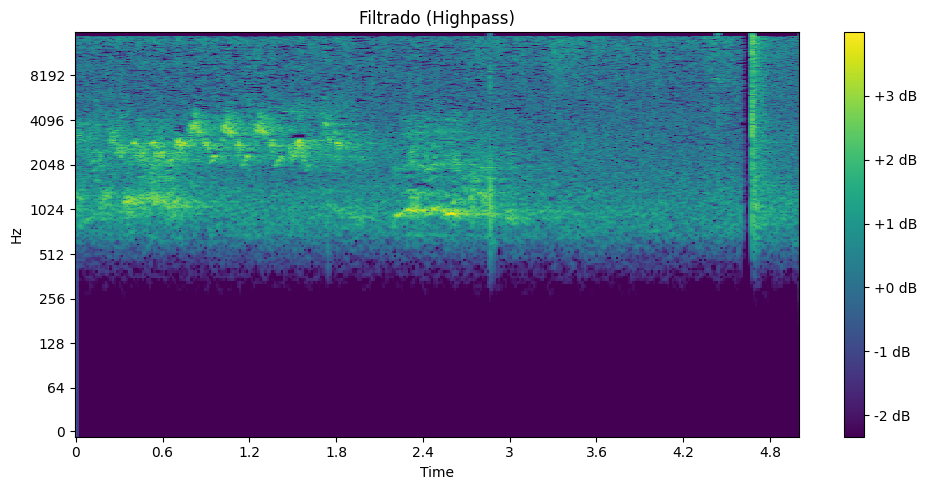

In [137]:
import librosa
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 5))

librosa.display.specshow(spec, sr=32000, x_axis='time', y_axis='log', cmap='viridis')
plt.title("Filtrado (Highpass)")
plt.colorbar(format='%+2.0f dB')

plt.tight_layout()
plt.show()